## Install Dependencies

In [93]:
# !pip install -q langchain==0.3.14
# !pip install -q langchain-openai==0.3.0
# !pip install -q langchain-community==0.3.14
# !pip install -q langgraph==0.2.64
# !pip install -q databricks-vectorsearch
# !pip install -U -qqqq databricks-langchain
# !pip install -q pyyaml
# # !pip install -q jq

In [94]:
# !pip install -q langchain_core

In [95]:
# !pip install --force-reinstall langgraph==0.2.64 --no-deps

In [96]:
# dbutils.library.restartPython()

In [97]:
from langgraph.prebuilt import ToolNode

In [98]:
# ============================================================================
# SETUP: Import Libraries & Load Configuration
# ============================================================================
# All tuneable parameters (endpoints, prompts, messages, etc.) are loaded
# from config.yml so the notebook stays clean and easy to maintain.

import os
import sys
import yaml

# # Add parent directory to path for importing helpers
# sys.path.append(os.path.abspath("../../.."))

# # ---- Load configuration ----
# CONFIG_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "config.yml")

with open("./config.yml", "r") as f:
    config = yaml.safe_load(f)

In [99]:
os.environ["DATABRICKS_TOKEN"] = config["databricks"]["token"]
os.environ["DATABRICKS_HOST"] = config["databricks"]["host"]

In [100]:
from databricks.vector_search.client import VectorSearchClient
vs_client = VectorSearchClient(disable_notice=True)

In [101]:
INDEX_NAME = config["vector_search"]["index_name"]
ENDPOINT_NAME = config["vector_search"]["endpoint_name"]
TABLE_NAME = config["vector_search"]["source_table"]
VS_COLUMNS = config["vector_search"]["columns"]
VS_QUERY_TYPE = config["vector_search"]["query_type"]

# Get the vector search index
vs_index = vs_client.get_index(endpoint_name=ENDPOINT_NAME, index_name=INDEX_NAME)
print(f"Connected to Vector Search Index: {INDEX_NAME}")
print(f"Endpoint: {ENDPOINT_NAME}")
print(f"Source Table: {TABLE_NAME}")

Connected to Vector Search Index: agentic_ai.langgraph.it_support_kb_index
Endpoint: one-env-shared-endpoint-1
Source Table: agentic_ai.langgraph.it_support_kb_chunks


## Setup Environment Variables & LLM

We use **Databricks Foundation Model APIs** via `ChatDatabricks` so no external API keys are needed.

In [102]:
from databricks_langchain import ChatDatabricks

# Use a Databricks-hosted LLM endpoint (configured in config.yml)
LLM_ENDPOINT_NAME = config["llm"]["endpoint_name"]
llm = ChatDatabricks(endpoint=LLM_ENDPOINT_NAME)
print(f"LLM endpoint: {LLM_ENDPOINT_NAME}")

LLM endpoint: databricks-claude-3-7-sonnet


In [103]:
from langchain_core.documents import Document
from typing import List

def convert_vector_search_to_documents(results) -> List[Document]:
    """
    Convert Databricks Vector Search results to LangChain Document objects.
    
    The first column retrieved is loaded into page_content,
    and the rest (except the score column) into metadata.
    """
    column_names = [col["name"] for col in results["manifest"]["columns"]]
    
    langchain_docs = []
    for item in results["result"]["data_array"]:
        metadata = {}
        # Last element is the similarity score
        score = item[-1]
        # First element is page_content, middle elements are metadata
        for i in range(1, len(item) - 1):
            metadata[column_names[i]] = item[i]
        metadata["score"] = score
        doc = Document(page_content=item[0], metadata=metadata)
        langchain_docs.append(doc)
    
    return langchain_docs

## Define the IT Support State

We create an `ITSupportState` typed dictionary that tracks data through the dynamic tool-based workflow:

- **ticket_description**: The DevOps ticket text (input)
- **business_unit**: Business Unit from the ticket API (e.g., "PL", "Growth SE") — **NOT derived from the ticket text**
- **workflow_type**: Workflow Type from the ticket API (e.g., "RapidLR", "PLPPL") — **NOT derived from the ticket text**
- **messages**: Agent ↔ Tool conversation history (accumulates tool calls and results)
- **rag_context**: Retrieved knowledge base context (similar past tickets and resolution steps)
- **final_response**: The final RCA report

In [104]:
from typing import TypedDict, Annotated, List
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# ============================================================================
# State: carries all data through the graph
# ============================================================================
# NOTE: business_unit and workflow_type are provided directly from the ticket
# API call — they are NOT derived from the ticket text by the agent.
# For now, they are passed as hardcoded values when invoking the agent.

class ITSupportState(TypedDict):
    ticket_description: str                                   # Input: DevOps ticket text
    business_unit: str                                        # Input: from ticket API (e.g., "PL", "Growth SE")
    workflow_type: str                                        # Input: from ticket API (e.g., "RapidLR", "PLPPL")
    messages: Annotated[list, add_messages]                   # Agent ↔ Tool conversation history
    rag_context: str                                          # Retrieved knowledge base context
    final_response: str                                       # Final output / RCA report
    ticket_type: str                                          # Derived from RAG (e.g. log_lookup, workflow_jobs); empty if not derived
    rag_top_score: float                                      # Top retrieval similarity score (0.0–1.0)
    rag_top_ticket_type: str                                  # ticket_type of the top-scoring RAG doc
    rag_relevant: bool                                        # LLM-verified: is the top RAG result actually relevant to the ticket?
    escalate_to_human: bool                                   # True when confidence < 90% or ticket_type not recognized -> route to human

### Architecture Overview — Two-Route Workflow with Route-Specific Tools

The workflow uses a **ReAct (Reasoning + Acting) agent** pattern with exactly **two routes** determined by `ticket_type` (derived from RAG). Each route has its own dedicated tool set.

1. **Receive Ticket** — The agent receives the DevOps ticket along with `business_unit` and `workflow_type` (provided directly from the ticket API, NOT derived from the text).
2. **Classify & Retrieve Knowledge** — RAG retrieval from the vector search index finds similar past tickets. The system derives `ticket_type` (`log_lookup` or `workflow_jobs`) and verifies confidence. Low confidence → escalate to human.
3. **Route by ticket_type** (each route binds only its own tools to the LLM):
   - **`log_lookup`** — `query_log_view` first, then one of 3 sub-routes based on status:
     - **no_data** → `check_upstream_source`
     - **eligible** → `check_downstream_integration`
     - **excluded** → `analyze_exclusion_reason`
     - Tools: `query_log_view`, `check_upstream_source`, `check_downstream_integration`, `analyze_exclusion_reason`, `update_devops_ticket`
   - **`workflow_jobs`** — Master table ops, pipeline checks, control flags, etc.
     - Tools: `refresh_master_table`, `update_master_table`, `check_control_flags`, `run_pipeline_check`, `send_email_notification`, `update_devops_ticket`
4. **Agent with Tools** (ReAct loop) — The LLM agent selects and executes tools within the chosen route.
5. **Generate Final Output** — Route-dependent:
   - **`log_lookup`**: returns the raw tool findings directly (e.g. exclusion reason from log table). **No RCA generated.**
   - **`workflow_jobs`**: generates a full RCA report via the LLM.

In [105]:
# Quick validation of the State
sample_state = ITSupportState(
    ticket_description="Test ticket",
    business_unit="PL",
    workflow_type="RapidLR",
    messages=[],
    rag_context="",
    final_response="",
    ticket_type="",
    rag_top_score=0.0,
    rag_top_ticket_type="",
    rag_relevant=True,
    escalate_to_human=False,
)
print(f"State fields: {list(sample_state.keys())}")
print(f"Business Unit (from ticket API): {sample_state['business_unit']}")
print(f"Workflow Type (from ticket API): {sample_state['workflow_type']}")

State fields: ['ticket_description', 'business_unit', 'workflow_type', 'messages', 'rag_context', 'final_response', 'ticket_type', 'rag_top_score', 'rag_top_ticket_type', 'rag_relevant', 'escalate_to_human']
Business Unit (from ticket API): PL
Workflow Type (from ticket API): RapidLR


In [106]:
# Note: business_unit and workflow_type are now direct inputs from the ticket API.
# The agent no longer needs to classify them from the ticket text.
# This simplifies the workflow and makes it more reliable.

## Define Tools & Graph Nodes

The agent uses **route-specific tools** — only the tools relevant to the ticket type are bound to the LLM.

**log_lookup tools** (5):

| # | Tool | Description |
|---|------|-------------|
| 1 | **query_log_view** | Query the RapidLR PL log view using log IDs |
| 2 | **check_upstream_source** | Check upstream data source (no_data sub-route) |
| 3 | **check_downstream_integration** | Check CRM / Dialer connectivity (eligible sub-route) |
| 4 | **analyze_exclusion_reason** | Investigate why records were excluded (excluded sub-route) |
| 5 | **update_devops_ticket** | Update DevOps ticket with findings |

**workflow_jobs tools** (6):

| # | Tool | Description |
|---|------|-------------|
| 1 | **refresh_master_table** | Refresh/sync a master table in cache memory |
| 2 | **update_master_table** | Update configuration values in a master table |
| 3 | **check_control_flags** | Verify control flag values in master tables |
| 4 | **run_pipeline_check** | Run health check on a data pipeline |
| 5 | **send_email_notification** | Send email to stakeholders |
| 6 | **update_devops_ticket** | Update DevOps ticket with findings |

**Graph Nodes:** `retrieve_knowledge` → `verify_relevance` → `derive_ticket_type` → `agent_node` ↔ `tool_node` → `generate_final_output`

In [107]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

# ==========================================================================
# NODE 1: Retrieve Knowledge  (RAG — Vector Search)
# ==========================================================================
def retrieve_knowledge(state: ITSupportState) -> ITSupportState:
    """
    Retrieves relevant knowledge from the vector search index based on the
    ticket description. This provides context about similar past tickets
    and their resolution steps.

    NOTE: business_unit and workflow_type are provided directly from the
    ticket API — they are NOT classified by the agent.
    """
    ticket = state["ticket_description"]
    bu = state.get("business_unit", "unknown")
    wf_type = state.get("workflow_type", "unknown")

    print(f"[Retrieve Knowledge] Business Unit (from ticket API): {bu}")
    print(f"[Retrieve Knowledge] Workflow Type (from ticket API): {wf_type}")
    print(f"[Retrieve Knowledge] Ticket: {ticket[:100]}...")

    # Search vector index for similar past tickets and resolution steps
    results = vs_index.similarity_search(
        query_text=ticket,
        columns=VS_COLUMNS,
        num_results=3,
        query_type=VS_QUERY_TYPE,
    )

    docs = convert_vector_search_to_documents(results)

    # Extract top retrieval score and its ticket_type for confidence routing
    rag_top_score = float(docs[0].metadata.get("score", 0.0)) if docs else 0.0
    rag_top_ticket_type = docs[0].metadata.get("ticket_type", "") if docs else ""

    # Format RAG context with ticket_type for better agent understanding
    rag_context_parts = []
    for doc in docs:
        ticket_type = doc.metadata.get("ticket_type", "unknown")
        score = doc.metadata.get("score", 0.0)
        rag_context_parts.append(f"[Similar Ticket — Type: {ticket_type} | Score: {score:.4f}]\n{doc.page_content}")
    rag_context = "\n\n---\n\n".join(rag_context_parts)

    print(f"[Retrieve Knowledge] Retrieved {len(docs)} relevant documents from knowledge base.")
    print(f"[Retrieve Knowledge] Top score: {rag_top_score:.4f} | Top ticket_type: {rag_top_ticket_type}")

    # Create the initial message for the agent with full context
    initial_message = HumanMessage(content=(
        f"Investigate the following IT support ticket:\n\n"
        f"**Ticket Description:** {ticket}\n"
        f"**Business Unit (from ticket API):** {bu}\n"
        f"**Workflow Type (from ticket API):** {wf_type}\n\n"
        f"**Similar Past Tickets & Resolution Steps (from Knowledge Base):**\n"
        f"{rag_context}\n\n"
        f"Use the available tools to investigate and resolve this ticket. "
        f"Follow the resolution patterns from similar past tickets when applicable. "
        f"When you have completed your investigation, provide a clear summary of findings."
    ))

    return {
        "rag_context": rag_context,
        "rag_top_score": rag_top_score,
        "rag_top_ticket_type": rag_top_ticket_type,
        "messages": [initial_message],
    }


## Derive ticket type and human escalation

After RAG retrieval, the system runs a two-stage relevance check:

1. **LLM Relevance Verification** (`verify_relevance`) — An LLM call checks whether the top RAG result is *semantically* relevant to the ticket. This guards against inflated vector similarity scores on out-of-domain queries (a known limitation of small KBs).
2. **Derive Ticket Type** (`derive_ticket_type`) — If the LLM confirms relevance AND the top score is **>= 90%** AND the ticket_type is a known type (`log_lookup` or `workflow_jobs`), the flow continues to the main agent. Otherwise, the flow is routed to a **human operator** for review.

In [108]:
# ==========================================================================
# Dummy: Human operator escalation (placeholder for real integration)
# ==========================================================================
def escalate_to_human_operator(ticket_description: str, ticket_type: str, reason: str) -> None:
    """Placeholder: in production this would create a task for a human (e.g. queue, ticket update)."""
    print("[Human Operator] Ticket escalated for manual review.")
    print(f"  Reason: {reason}")
    print(f"  Derived ticket_type: {ticket_type or '(none)'}")
    print(f"  Ticket preview: {ticket_description[:120]}...")


# ==========================================================================
# NODE: Verify RAG Relevance (LLM-based semantic guard)
# ==========================================================================
def verify_relevance(state: ITSupportState) -> ITSupportState:
    """
    Uses the LLM to verify whether the top RAG result is genuinely relevant
    to the ticket. Raw vector similarity scores are unreliable as an absolute
    relevance measure — a small KB will return high scores even for completely
    unrelated queries. This node acts as a semantic guard.
    """
    ticket = state.get("ticket_description", "")
    rag_context = state.get("rag_context", "")
    top_score = state.get("rag_top_score", 0.0) or 0.0

    if not rag_context or top_score == 0.0:
        print("[Verify Relevance] No RAG context to verify. Marking as not relevant.")
        return {"rag_relevant": False}

    # Extract just the top entry (first section before the separator)
    rag_top_entry = rag_context.split("\n\n---\n\n")[0]

    prompt_template = config["prompts"]["rag_relevance_check"]
    prompt = prompt_template.format(
        ticket_description=ticket,
        rag_top_entry=rag_top_entry,
    )

    verdict = llm.invoke(prompt).content.strip().upper()
    is_relevant = "RELEVANT" in verdict and "NOT_RELEVANT" not in verdict

    print(f"[Verify Relevance] LLM verdict: {verdict} → rag_relevant={is_relevant}")
    return {"rag_relevant": is_relevant}


# ==========================================================================
# NODE: Derive ticket type from RAG context
# ==========================================================================
CONFIDENCE_THRESHOLD = 0.90
KNOWN_TICKET_TYPES = {"log_lookup", "workflow_jobs"}

def derive_ticket_type(state: ITSupportState) -> ITSupportState:
    """
    Derives ticket_type using:
      1. LLM relevance verdict (rag_relevant) — must be True
      2. Top RAG retrieval score >= threshold
      3. Top ticket_type is a known type

    All three must pass; otherwise escalate to human operator.
    """
    top_score = state.get("rag_top_score", 0.0) or 0.0
    top_type = (state.get("rag_top_ticket_type", "") or "").strip()
    rag_relevant = state.get("rag_relevant", False)

    confident = (
        rag_relevant
        and top_score >= CONFIDENCE_THRESHOLD
        and top_type in KNOWN_TICKET_TYPES
    )
    ticket_type = top_type if confident else ""
    escalate_to_human = not confident

    print(f"[Derive Ticket Type] rag_relevant: {rag_relevant}")
    print(f"[Derive Ticket Type] Top RAG score: {top_score:.4f} (threshold: {CONFIDENCE_THRESHOLD})")
    print(f"[Derive Ticket Type] Top ticket_type: {top_type or '(none)'} | known: {top_type in KNOWN_TICKET_TYPES}")
    print(f"[Derive Ticket Type] Derived ticket_type: {ticket_type or '(none)'} | escalate_to_human: {escalate_to_human}")
    return {"ticket_type": ticket_type, "escalate_to_human": escalate_to_human}


def route_after_derive(state: ITSupportState) -> str:
    """Route to human operator if not relevant, score < 90%, or ticket_type not recognized."""
    if state.get("escalate_to_human"):
        return "human_operator"
    return "agent"


# ==========================================================================
# NODE: Human operator (dummy — prints and sets final_response)
# ==========================================================================
def human_operator_node(state: ITSupportState) -> ITSupportState:
    """Runs the dummy human-escalation flow and returns a final_response so the run ends."""
    ticket_type = state.get("ticket_type", "") or ""
    ticket_description = state.get("ticket_description", "") or ""
    top_score = state.get("rag_top_score", 0.0) or 0.0
    top_type = state.get("rag_top_ticket_type", "") or ""
    rag_relevant = state.get("rag_relevant", False)
    reason = (
        f"rag_relevant={rag_relevant}, top_score={top_score:.4f} "
        f"(threshold={CONFIDENCE_THRESHOLD}), "
        f"ticket_type='{top_type}' (known={top_type in KNOWN_TICKET_TYPES}); "
        f"routing to human."
    )
    escalate_to_human_operator(
        ticket_description=ticket_description,
        ticket_type=ticket_type,
        reason=reason,
    )
    msg = "[ESCALATED TO HUMAN] A human operator will review this ticket."
    return {"final_response": msg}


In [109]:
# Test retrieve_knowledge with a sample ticket
test_ticket = """IT Request 8071210: Data is not pushing on Prospect Staging for Growth SE.
As discussed, please check the below sample logs ID, the data are not pushing on
prospect staging of Growth SE business despite all masters have been updated.
Log IDs: 09508632-bbb4-45d8-8651-fbe8b044494e, a4150cd0-d148-4fef-96f0-1274b8635ca6"""

result = retrieve_knowledge({
    "ticket_description": test_ticket,
    "business_unit": "Growth SE",
    "workflow_type": "PLPPL",
})
print(f"\nRAG Context (first 500 chars):\n{result['rag_context'][:500]}...")
print(f"\nInitial message created: {type(result['messages'][0]).__name__}")

[Retrieve Knowledge] Business Unit (from ticket API): Growth SE
[Retrieve Knowledge] Workflow Type (from ticket API): PLPPL
[Retrieve Knowledge] Ticket: IT Request 8071210: Data is not pushing on Prospect Staging for Growth SE.
As discussed, please chec...
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[Retrieve Knowledge] Retrieved 3 relevant documents from knowledge base.
[Retrieve Knowledge] Top score: 1.0000 | Top ticket_type: log_lookup

RAG Context (first 500 chars):
[Similar Ticket — Type: log_lookup | Score: 1.0000]
Please check the below sample logs ID, the data are not pushing on prospect staging of Growth SE business despite all masters have been updated. logId: 09508632-bbb4-45d8-8651-fbe8b044494e, a4150cd0-d148-4fef-96f0-1274b8635ca6, 1d776a1c-95c9-4ab3-9830-2b5f780a06d9

Resolution Steps:
  1. query_log_view wit

In [110]:
# Test retrieve_knowledge with a workflow-type ticket
test_ticket_wf = """IT Request 8071345: PLPPL workflow pipeline failing intermittently.
The RapidLR PL pipeline for PLPPL is throwing errors during the Business Rule Engine
evaluation step. Need to investigate the EDS-RapidLR-PL repository code path."""

result_wf = retrieve_knowledge({
    "ticket_description": test_ticket_wf,
    "business_unit": "PL",
    "workflow_type": "PLPPL",
})
print(f"\nRAG Context (first 500 chars):\n{result_wf['rag_context'][:500]}...")

[Retrieve Knowledge] Business Unit (from ticket API): PL
[Retrieve Knowledge] Workflow Type (from ticket API): PLPPL
[Retrieve Knowledge] Ticket: IT Request 8071345: PLPPL workflow pipeline failing intermittently.
The RapidLR PL pipeline for PLPP...
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[Retrieve Knowledge] Retrieved 3 relevant documents from knowledge base.
[Retrieve Knowledge] Top score: 1.0000 | Top ticket_type: workflow_jobs

RAG Context (first 500 chars):
[Similar Ticket — Type: workflow_jobs | Score: 1.0000]
The PLPPL workflow pipeline is failing intermittently. The RapidLR PL pipeline for PLPPL offerProduct is throwing errors during the Business Rule Engine evaluation step. Need to investigate the EDS-RapidLR-PL repository code path and validate the master table configurations for plCtaControlMaster.

Resoluti

In [111]:
from langchain_core.tools import tool

# ==========================================================================
# TOOL DEFINITIONS
# ==========================================================================
# Each tool performs a specific IT support action. The agent dynamically
# selects which tools to call based on the ticket content and context.
# In production, these would connect to actual systems. Currently they
# return simulated results for demonstration.
# ==========================================================================

@tool
def refresh_master_table(table_name: str) -> str:
    """Refresh/sync a master table in cache memory. Use this when a master table
    needs to be refreshed after updates at the source (e.g., after ICORS refresh).

    Args:
        table_name: Fully qualified table name (e.g., bfl_std_lake.rtl_cc.rpl_rapidlr_branch_campaign_master)
    """
    print(f"  [Tool: refresh_master_table] Refreshing: {table_name}")
    return (
        f"Master table '{table_name}' has been refreshed successfully in cache memory. "
        f"Sync completed. All records are up to date."
    )


@tool
def update_master_table(table_name: str, update_description: str) -> str:
    """Update configuration values in a master table. Use this when specific values
    need to be changed (e.g., control flags, campaign mappings, branch allocations).

    Args:
        table_name: Fully qualified table name to update
        update_description: Description of what to update (e.g., 'Set sfdcFlag=true for GROWTH_SE')
    """
    print(f"  [Tool: update_master_table] Updating: {table_name}")
    print(f"  [Tool: update_master_table] Changes: {update_description}")
    return (
        f"Master table '{table_name}' updated successfully.\n"
        f"Changes applied: {update_description}\n"
        f"Note: Run refresh_master_table to sync changes to cache memory."
    )


@tool
def query_log_view(log_ids: str) -> str:
    """Query the RapidLR PL log view (agentic_ai.langgraph.sample_log_files_rlr_pl)
    using log IDs to check record eligibility/exclusion status and processing details
    by parsing the extendedDetails JSON column.

    Args:
        log_ids: Comma-separated log IDs (eventId / correlationId) to look up
    """
    log_view = config["it_support"]["log_view"]
    schema = config["it_support"]["extended_details_schema"]
    print(f"  [Tool: query_log_view] Querying {log_view}")
    print(f"  [Tool: query_log_view] Log IDs: {log_ids}")

    # Parse and sanitise log IDs
    ids = [lid.strip() for lid in log_ids.split(",") if lid.strip()]
    id_list = ", ".join([f"'{lid}'" for lid in ids])

    # Query the actual log table, extracting key fields from extendedDetails
    query = f"""
        SELECT
            `eventId`,
            correlationId,
            product,
            process,
            subProcess,
            from_json(extendedDetails, '{schema}').status          AS status,
            from_json(extendedDetails, '{schema}').statusReason    AS statusReason,
            from_json(extendedDetails, '{schema}').source          AS source,
            from_json(extendedDetails, '{schema}').responseBusiness AS responseBusiness,
            from_json(extendedDetails, '{schema}').identifier      AS identifier
        FROM {log_view}
        WHERE `eventId` IN ({id_list})
           OR correlationId IN ({id_list})
    """

    print(f"  [Tool: query_log_view] Query:\n{query}")

    df = spark.sql(query)
    results = df.collect()

    if not results:
        return (
            f"No records found in {log_view} for the provided log IDs: {log_ids}.\n"
            f"The records may not exist in the log table or the IDs may be incorrect."
        )

    output_parts = [
        f"Query executed on {log_view}.",
        f"Log IDs queried: {log_ids}",
        f"Results ({len(results)} record(s) found):\n",
    ]

    for i, row in enumerate(results, 1):
        eid = row["eventId"] or "N/A"
        output_parts.append(
            f"  Record {i}: eventId={eid} | "
            f"status={row['status']} | statusReason={row['statusReason']} | "
            f"source={row['source']} | responseBusiness={row['responseBusiness']} | "
            f"identifier={row['identifier']}"
        )

    # Status summary
    statuses = [row["status"] for row in results]
    eligible = statuses.count("Eligible")
    excluded = statuses.count("Excluded")
    other = len(statuses) - eligible - excluded
    output_parts.append(
        f"\n  Status summary: {eligible} Eligible, {excluded} Excluded"
        + (f", {other} Other" if other else "")
        + f" out of {len(results)} total records."
    )

    return "\n".join(output_parts)


@tool
def check_downstream_integration(system_name: str) -> str:
    """Check connectivity and data flow to a downstream system (e.g., SFDC CRM, Dialer).
    Use this to verify that the downstream system is receiving data correctly.

    Args:
        system_name: Name of the downstream system to check (e.g., 'SFDC CRM', 'Dialer')
    """
    print(f"  [Tool: check_downstream_integration] Checking: {system_name}")
    return (
        f"Downstream system '{system_name}' check:\n"
        f"  - Connectivity: OK\n"
        f"  - Data flow: Active\n"
        f"  - Last successful sync: 2 minutes ago\n"
        f"  - No issues detected at the integration layer.\n"
        f"  - If data is not reaching {system_name}, the issue is likely upstream "
        f"(control flags, master configuration, or processing pipeline)."
    )


@tool
def check_upstream_source(source_name: str) -> str:
    """Check the upstream data source when records are missing or data is not flowing.
    Use this to verify if data was ever received from the source system.

    Args:
        source_name: Name or identifier of the upstream source to check
    """
    print(f"  [Tool: check_upstream_source] Checking upstream: {source_name}")
    return (
        f"Upstream source '{source_name}' check:\n"
        f"  - Source status: Active\n"
        f"  - Data ingestion: Records present at source level\n"
        f"  - Last data received: Within the last hour\n"
        f"  - If records are missing downstream, the issue likely occurs during "
        f"the processing/filtering stage, not at ingestion."
    )

In [112]:
@tool
def analyze_exclusion_reason(log_ids: str) -> str:
    """Analyze why records were excluded from processing by querying the log table
    for records with status='Excluded' and extracting the statusReason from
    extendedDetails. Use this when query_log_view shows Excluded status.

    Args:
        log_ids: Comma-separated log IDs of excluded records to analyze
    """
    log_view = config["it_support"]["log_view"]
    schema = config["it_support"]["extended_details_schema"]
    repo = config["it_support"]["devops_repository"]
    print(f"  [Tool: analyze_exclusion_reason] Analyzing exclusion for: {log_ids}")

    # Parse and sanitise log IDs
    ids = [lid.strip() for lid in log_ids.split(",") if lid.strip()]
    id_list = ", ".join([f"'{lid}'" for lid in ids])

    query = f"""
    SELECT
    `eventId`,
    from_json(extendedDetails, 'STRUCT<status: STRING, statusReason: STRING, source: STRING, internalSource: STRING, responseBusiness: STRING, identifier: STRING>').status           AS status,
    from_json(extendedDetails, 'STRUCT<status: STRING, statusReason: STRING, source: STRING, internalSource: STRING, responseBusiness: STRING, identifier: STRING>').statusReason      AS statusReason,
    from_json(extendedDetails, 'STRUCT<status: STRING, statusReason: STRING, source: STRING, internalSource: STRING, responseBusiness: STRING, identifier: STRING>').source            AS source,
    from_json(extendedDetails, 'STRUCT<status: STRING, statusReason: STRING, source: STRING, internalSource: STRING, responseBusiness: STRING, identifier: STRING>').internalSource    AS internalSource,
    from_json(extendedDetails, 'STRUCT<status: STRING, statusReason: STRING, source: STRING, internalSource: STRING, responseBusiness: STRING, identifier: STRING>').responseBusiness  AS responseBusiness,
    from_json(extendedDetails, 'STRUCT<status: STRING, statusReason: STRING, source: STRING, internalSource: STRING, responseBusiness: STRING, identifier: STRING>').identifier        AS identifier
FROM agentic_ai.langgraph.sample_log_files_rlr_pl
WHERE (`eventId` IN ({id_list}) OR correlationId IN ({id_list}))
  AND from_json(extendedDetails, 'STRUCT<status: STRING>').status = 'Excluded'"""


    df = spark.sql(query)
    results = df.collect()

    if not results:
        return (
            f"No excluded records found for log IDs: {log_ids}.\n"
            f"The records may be Eligible, or the log IDs were not found in {log_view}.\n"
            f"Use query_log_view to check the actual status of these log IDs."
        )

    output_parts = [
        f"Exclusion Analysis for log IDs ({log_ids}):",
        f"  Source table: {log_view}",
        f"  {len(results)} excluded record(s) found:\n",
    ]

    for i, row in enumerate(results, 1):
        eid = row["eventId"] or "N/A"
        output_parts.append(
            f"  {i}. eventId={eid}\n"
            f"     Status: {row['status']}\n"
            f"     Exclusion Reason: {row['statusReason']}\n"
            f"     Source: {row['source']} (internal: {row['internalSource']})\n"
            f"     Response Business: {row['responseBusiness']}\n"
            f"     Identifier (offerProduct): {row['identifier']}"
        )

    # Group and summarise exclusion reasons
    reasons = {}
    for row in results:
        reason = row["statusReason"] or "Unknown"
        reasons[reason] = reasons.get(reason, 0) + 1

    output_parts.append(f"\n  Exclusion Reason Summary:")
    for reason, count in sorted(reasons.items(), key=lambda x: -x[1]):
        output_parts.append(f"    - {reason}: {count} record(s)")

    output_parts.append(
        f"\n  Repository: {repo}"
        f"\n  Recommended: Investigate the exclusion reasons above. Check corresponding "
        f"master table configurations and control flags for the affected "
        f"offerProduct/responseBusiness combinations."
    )

    return "\n".join(output_parts)


@tool
def check_control_flags(table_name: str, flag_names: str) -> str:
    """Check the values of control flags in a master table to verify configuration.
    Common flags include sendToSfdc, sfdcFlag, etc.

    Args:
        table_name: The master table to check (e.g., 'plCtaControlMaster')
        flag_names: Comma-separated list of flag names to check (e.g., 'sendToSfdc, sfdcFlag')
    """
    print(f"  [Tool: check_control_flags] Table: {table_name}, Flags: {flag_names}")
    flags = [f.strip() for f in flag_names.split(",")]
    results = []
    for flag in flags:
        if "sfdc" in flag.lower() and "send" not in flag.lower():
            results.append(f"  {flag}: false (⚠ INCORRECT — should be true)")
        else:
            results.append(f"  {flag}: true (✓ correct)")
    return (
        f"Control flag check on '{table_name}':\n"
        + "\n".join(results)
        + f"\n  ⚠ Flag mismatch detected — this is preventing data from flowing to downstream systems."
    )

In [113]:
@tool
def run_pipeline_check(pipeline_name: str) -> str:
    """Run a health check on a specific data pipeline to verify it is operating correctly.
    Use this to diagnose pipeline failures or verify pipeline health after fixes.

    Args:
        pipeline_name: Name of the pipeline to check (e.g., 'EDS-RapidLR-PL')
    """
    print(f"  [Tool: run_pipeline_check] Checking pipeline: {pipeline_name}")
    return (
        f"Pipeline '{pipeline_name}' health check:\n"
        f"  - Data ingestion stage: PASSED\n"
        f"  - Business Rule Engine (BRE): PASSED\n"
        f"  - Master table validation: WARNING — Flag mismatch detected in plCtaControlMaster\n"
        f"  - Downstream sync (SFDC): BLOCKED — sfdcFlag=false for some offerProduct/responseBusiness\n"
        f"  - Overall status: ATTENTION NEEDED — master configuration issue detected"
    )


@tool
def send_email_notification(recipient: str, subject: str, body: str) -> str:
    """Send an email notification to stakeholders about the ticket status or resolution.
    Use this to notify teams about completed actions, findings, or escalations.

    Args:
        recipient: Email recipient(s) — can be a name or email address
        subject: Email subject line
        body: Email body content
    """
    print(f"  [Tool: send_email_notification] To: {recipient} | Subject: {subject}")
    return f"Email sent successfully to '{recipient}'. Subject: '{subject}'."


@tool
def update_devops_ticket(ticket_id: str, comment: str) -> str:
    """Update a DevOps ticket with investigation findings, status changes, or resolution notes.
    Use this to document the investigation progress and final resolution.

    Args:
        ticket_id: The DevOps ticket ID (e.g., 'IT-8071210')
        comment: The comment/findings to add to the ticket
    """
    print(f"  [Tool: update_devops_ticket] Updating ticket: {ticket_id}")
    return (
        f"DevOps ticket '{ticket_id}' updated successfully.\n"
        f"Comment added: {comment[:100]}...\n"
        f"Ticket status changed to 'In Progress'."
    )

In [114]:
from langgraph.prebuilt import ToolNode

# ==========================================================================
# TOOL LISTS — separated by route
# ==========================================================================
# log_lookup route: query_log_view first, then one of 3 sub-routes
#   no_data   → check_upstream_source
#   eligible  → check_downstream_integration
#   excluded  → analyze_exclusion_reason
# Plus update_devops_ticket for final output.
log_lookup_tools = [
    query_log_view,
    check_upstream_source,
    check_downstream_integration,
    analyze_exclusion_reason,
    update_devops_ticket,
]

# workflow_jobs route: master table ops, pipeline checks, control flags, etc.
workflow_jobs_tools = [
    refresh_master_table,
    update_master_table,
    check_control_flags,
    run_pipeline_check,
    send_email_notification,
    update_devops_ticket,
]

# All tools combined — used by the ToolNode executor
all_tools = list({t.name: t for t in log_lookup_tools + workflow_jobs_tools}.values())

# Create the ToolNode that can execute any tool the agent calls
tool_node = ToolNode(all_tools)

print(f"log_lookup tools ({len(log_lookup_tools)}):")
for t in log_lookup_tools:
    print(f"  - {t.name}")
print(f"\nworkflow_jobs tools ({len(workflow_jobs_tools)}):")
for t in workflow_jobs_tools:
    print(f"  - {t.name}")
print(f"\nToolNode registered {len(all_tools)} unique tools.")

log_lookup tools (5):
  - query_log_view
  - check_upstream_source
  - check_downstream_integration
  - analyze_exclusion_reason
  - update_devops_ticket

workflow_jobs tools (6):
  - refresh_master_table
  - update_master_table
  - check_control_flags
  - run_pipeline_check
  - send_email_notification
  - update_devops_ticket

ToolNode registered 10 unique tools.


In [115]:
# ==========================================================================
# NODE 2: Agent Node  (LLM with Tools — ReAct pattern)
# ==========================================================================
def agent_node(state: ITSupportState) -> ITSupportState:
    """
    The main agent node that uses the LLM to decide which tools to call.
    This implements the ReAct (Reasoning + Acting) pattern:
      1. The agent receives the ticket context + past tool results
      2. It reasons about what to do next
      3. It either calls a tool or provides a final summary

    Tool binding is route-specific:
      - log_lookup:    query_log_view, check_upstream_source,
                       check_downstream_integration, analyze_exclusion_reason,
                       update_devops_ticket
      - workflow_jobs: refresh_master_table, update_master_table,
                       check_control_flags, run_pipeline_check,
                       send_email_notification, update_devops_ticket
    """
    ticket_type = state.get("ticket_type", "unknown")

    # Select route-specific tools
    if ticket_type == "log_lookup":
        route_tools = log_lookup_tools
    else:
        route_tools = workflow_jobs_tools

    # Bind only the allowed tools for this route
    llm_with_route_tools = llm.bind_tools(route_tools)

    # Build system prompt with BU, workflow type, and ticket_type
    system_prompt = config["prompts"]["agent_system"].format(
        business_unit=state.get("business_unit", "unknown"),
        workflow_type=state.get("workflow_type", "unknown"),
        ticket_type=ticket_type,
    )

    # Prepend system message to the conversation
    messages = [SystemMessage(content=system_prompt)] + state["messages"]

    # Invoke LLM with route-specific tools
    response = llm_with_route_tools.invoke(messages)

    tool_calls = getattr(response, "tool_calls", [])
    if tool_calls:
        print(f"[Agent] [{ticket_type}] Calling {len(tool_calls)} tool(s): {[tc['name'] for tc in tool_calls]}")
    else:
        print(f"[Agent] [{ticket_type}] Investigation complete. Generating summary.")

    return {"messages": [response]}

In [116]:
# ==========================================================================
# ROUTER: Should the agent continue calling tools or is it done?
# ==========================================================================
def should_continue(state: ITSupportState) -> str:
    """
    Checks the last message from the agent:
      - If it contains tool_calls → route to 'tools' (execute tools)
      - If no tool_calls → route to 'generate_final_output' (agent is done)
    """
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "generate_final_output"

In [117]:
# ==========================================================================
# NODE 3: Generate Final Output
# ==========================================================================
# - log_lookup:    returns tool findings directly (no RCA). The exclusion
#                  reason / upstream / downstream result IS the output.
# - workflow_jobs: generates a full RCA report via the LLM.
# ==========================================================================
def generate_final_output(state: ITSupportState) -> ITSupportState:
    from langchain_core.messages import ToolMessage

    ticket_type = state.get("ticket_type", "unknown")

    # Collect all tool execution results from the conversation
    tool_results = []
    for msg in state["messages"]:
        if isinstance(msg, ToolMessage):
            tool_results.append({"tool": msg.name, "result": msg.content})

    # ------------------------------------------------------------------
    # LOG LOOKUP — no RCA; return the log-table findings directly
    # ------------------------------------------------------------------
    if ticket_type == "log_lookup":
        log_lookup_tools = {"query_log_view", "analyze_exclusion_reason",
                            "check_upstream_source", "check_downstream_integration"}

        findings = []
        for tr in tool_results:
            if tr["tool"] in log_lookup_tools:
                findings.append(f"[{tr['tool']}]\n{tr['result']}")

        final_response = "\n\n".join(findings) if findings else "No log findings available."

        print(f"[Final Output] log_lookup — returning tool findings directly (no RCA).")
        print(f"[Final Output] Tools executed: {len(tool_results)}")
        return {"final_response": final_response}

    # ------------------------------------------------------------------
    # WORKFLOW JOBS — full RCA report via LLM
    # ------------------------------------------------------------------
    agent_summary = ""
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage) and not getattr(msg, "tool_calls", []):
            agent_summary = msg.content
            break

    investigation_details = "\n\n".join(
        f"[{tr['tool']}]: {tr['result']}" for tr in tool_results
    ) if tool_results else "No tool results available."

    prompt_template = config["prompts"]["final_rca_generation"]
    prompt = prompt_template.format(
        ticket_description=state.get("ticket_description", ""),
        business_unit=state.get("business_unit", ""),
        workflow_type=state.get("workflow_type", ""),
        agent_summary=agent_summary,
        investigation_details=investigation_details,
    )

    print(f"[Final Output] workflow_jobs — generating RCA report...")
    print(f"[Final Output] Tools executed: {len(tool_results)}")
    final_response = llm.invoke(prompt).content

    print(f"[Final Output] RCA report generated successfully.")

    return {"final_response": final_response}

## Build and Compile the Dynamic Workflow

The graph implements a **ReAct agent** pattern:

```
START → retrieve_knowledge → agent ↔ tools → generate_final_output → END
```

The agent dynamically decides which tools to call based on the ticket, BU, workflow type, and retrieved knowledge. The `should_continue` router controls the agent-tool loop.

In [118]:
# Routers are no longer needed — the agent dynamically decides which
# tools to call. The only routing decision is should_continue()
# (defined above), which checks if the agent wants more tools or is done.
print("Dynamic routing: agent decides tool calls via should_continue()")

Dynamic routing: agent decides tool calls via should_continue()


### Compile the Graph

The graph has the following nodes:
1. `retrieve_knowledge` → RAG retrieval + initial message creation
2. `verify_relevance` → LLM-based semantic guard against false-positive RAG matches
3. `derive_ticket_type` → Score + type check; routes to human or agent
4. `agent` → LLM reasons and decides tool calls (route-specific tools)
5. `tools` → Executes the requested tools (ToolNode)
6. `generate_final_output` → Route-dependent output:
   - **log_lookup**: returns tool findings directly (exclusion reason / upstream / downstream check) — **no RCA**
   - **workflow_jobs**: generates a full RCA report via LLM

In [119]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

# Create the graph with our IT Support state
graph = StateGraph(ITSupportState)

# ---- Add nodes ----
graph.add_node("retrieve_knowledge", retrieve_knowledge)    # RAG retrieval
graph.add_node("verify_relevance", verify_relevance)        # LLM-based relevance guard
graph.add_node("derive_ticket_type", derive_ticket_type)     # Derive ticket_type from RAG; may set escalate_to_human
graph.add_node("human_operator", human_operator_node)        # Dummy: escalate to human (print + final_response)
graph.add_node("agent", agent_node)                         # LLM agent (tool calling)
graph.add_node("tools", tool_node)                          # Tool executor
graph.add_node("generate_final_output", generate_final_output)  # RCA report

# ---- Entry point ----
graph.set_entry_point("retrieve_knowledge")

# ---- Edges ----
# 1. After RAG → verify relevance → derive ticket_type → route to human or agent
graph.add_edge("retrieve_knowledge", "verify_relevance")
graph.add_edge("verify_relevance", "derive_ticket_type")
graph.add_conditional_edges(
    "derive_ticket_type",
    route_after_derive,
    {"human_operator": "human_operator", "agent": "agent"},
)
graph.add_edge("human_operator", END)

# 2. Agent path: agent <-> tools -> generate_final_output

# 3. Agent decides: call more tools or generate final output
graph.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        "generate_final_output": "generate_final_output",
    },
)

# 4. After tools execute, loop back to agent for next decision
graph.add_edge("tools", "agent")

# 5. Final output goes to END
graph.add_edge("generate_final_output", END)

# ---- Compile ----
memory = MemorySaver()
compiled_agent = graph.compile(checkpointer=memory)

print("Graph compiled successfully!")
print(f"Flow: retrieve_knowledge → verify_relevance → derive_ticket_type (relevant & score>={CONFIDENCE_THRESHOLD} & type in {KNOWN_TICKET_TYPES}?) → (human_operator | agent ↔ tools → generate_final_output) → END")

Graph compiled successfully!
Flow: retrieve_knowledge → verify_relevance → derive_ticket_type (relevant & score>=0.9 & type in {'workflow_jobs', 'log_lookup'}?) → (human_operator | agent ↔ tools → generate_final_output) → END


## Visualize the Workflow

Below is a generated diagram of the workflow using Mermaid syntax. It shows how each node connects in the graph.

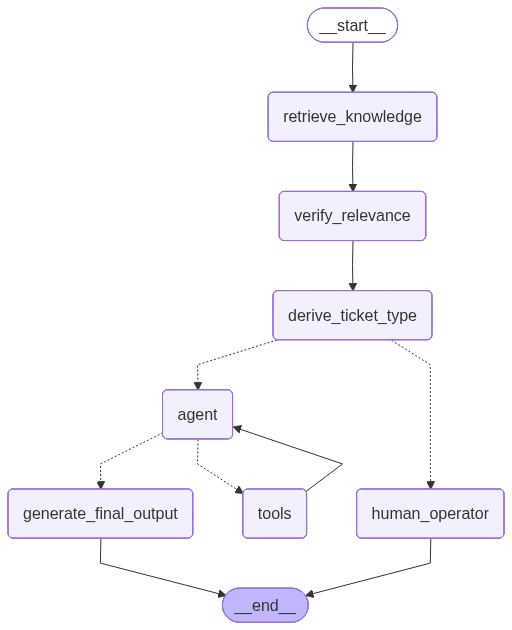

In [120]:
from IPython.display import display, Image, Markdown

display(Image(compiled_agent.get_graph().draw_mermaid_png()))

## Helper Function to Run the Workflow

This function takes a DevOps ticket description along with **business_unit** and **workflow_type** (provided from the ticket API) and runs it through the compiled IT Support workflow, streaming each step and displaying the final RCA report.

In [121]:
def call_it_support_agent(agent, ticket_description, business_unit, workflow_type, session_id, verbose=False):
    """
    Runs the IT Support Router agent with the given DevOps ticket.

    Args:
        agent: The compiled LangGraph agent
        ticket_description: The DevOps ticket text
        business_unit: Business Unit from ticket API (e.g., "Growth SE", "PL")
        workflow_type: Workflow Type from ticket API (e.g., "PLPPL", "RapidLR")
        session_id: Unique session ID for checkpointing
        verbose: If True, prints full event details

    NOTE: business_unit and workflow_type are provided directly from the ticket
    API call — they are NOT derived from the ticket text by the agent.
    """
    events = agent.stream(
        {
            "ticket_description": ticket_description,
            "business_unit": business_unit,
            "workflow_type": workflow_type,
            "ticket_type": "",
            "rag_top_score": 0.0,
            "rag_top_ticket_type": "",
            "rag_relevant": True,
            "escalate_to_human": False,
        },
        {"configurable": {"thread_id": session_id}, "recursion_limit": 50},
        stream_mode="values",
    )

    print("=" * 60)
    print(f"Running IT Support Agent")
    print(f"  Business Unit : {business_unit} (from ticket API)")
    print(f"  Workflow Type : {workflow_type} (from ticket API)")
    print("=" * 60)

    for event in events:
        if verbose:
            # Print a summary of the event, not the full messages (which can be large)
            keys = [k for k in event.keys() if k != "messages"]
            for k in keys:
                if event.get(k):
                    print(f"  [{k}]: {str(event[k])[:200]}")
            # Show message types and tool calls
            msgs = event.get("messages", [])
            if msgs:
                last = msgs[-1]
                msg_type = type(last).__name__
                if hasattr(last, "tool_calls") and last.tool_calls:
                    tools_called = [tc["name"] for tc in last.tool_calls]
                    print(f"  [message] {msg_type} → tool_calls: {tools_called}")
                elif hasattr(last, "name") and last.name:
                    print(f"  [message] {msg_type} from tool: {last.name}")
                else:
                    content_preview = str(last.content)[:150] if last.content else "(empty)"
                    print(f"  [message] {msg_type}: {content_preview}...")
            print("-" * 40)

    print("=" * 60)
    print("FINAL RESPONSE:")
    print("=" * 60)
    display(Markdown(event.get("final_response", "No response generated.")))

## Human Escalation

In [122]:
# ---- Test: Human operator escalation ----
# Ticket text is out-of-domain. Even if RAG returns some matches, the retrieval score
# should be below 90% OR the ticket_type won't be in {log_lookup, workflow_jobs},
# causing derive_ticket_type to set escalate_to_human=True -> flow goes to human_operator.

ticket_human_escalation = """
Dummy Ticket for Human Escalation.
responded.
"""

call_it_support_agent(
    agent=compiled_agent,
    ticket_description=ticket_human_escalation,
    business_unit="PL",
    workflow_type="PLPPL",
    session_id="ticket-human-escalation",
    verbose=True
)


Running IT Support Agent
  Business Unit : PL (from ticket API)
  Workflow Type : PLPPL (from ticket API)
  [ticket_description]: 
Dummy Ticket for Human Escalation.
responded.

  [business_unit]: PL
  [workflow_type]: PLPPL
  [rag_relevant]: True
----------------------------------------
[Retrieve Knowledge] Business Unit (from ticket API): PL
[Retrieve Knowledge] Workflow Type (from ticket API): PLPPL
[Retrieve Knowledge] Ticket: 
Dummy Ticket for Human Escalation.
responded.
...
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[Retrieve Knowledge] Retrieved 3 relevant documents from knowledge base.
[Retrieve Knowledge] Top score: 0.9692 | Top ticket_type: workflow_jobs
  [ticket_description]: 
Dummy Ticket for Human Escalation.
responded.

  [business_unit]: PL
  [workflow_type]: PLPPL
  [rag_context]: [Similar Ticket — Type:

[ESCALATED TO HUMAN] A human operator will review this ticket.

## Testing the Two-Route Workflow

Let's test the workflow with sample DevOps tickets derived from the IT Requests document. The agent follows one of **two routes** based on the derived `ticket_type`.

**Note:** `business_unit` and `workflow_type` are passed as hardcoded values (simulating the ticket API).

1. **Test 1** — Data not pushing to staging (`ticket_type=log_lookup` → agent uses log query, exclusion analysis, control flags, etc.)
2. **Test 2** — Pipeline failing (`ticket_type=workflow_jobs` → agent uses pipeline check, control flags, master update, etc.)
3. **Test 3** — Master table refresh (`ticket_type=workflow_jobs` → agent uses refresh, email notification, etc.)

In [123]:
# ---- Test 1: Clarification — Data not pushing to staging ----
# The agent should dynamically use: query_log_view, analyze_exclusion_reason,
# check_control_flags, check_downstream_integration, update_devops_ticket, etc.

ticket_clarification = """
IT Request 8071210: Data is not pushing on Prospect Staging for Growth SE

Description:
As discussed, please check the below sample logs ID, the data are not pushing on
prospect staging of Growth SE business despite all masters have been updated.

Log IDs:
05d073c8-ed99-42c0-98d0-21ec30d54f8b

By prospect staging they are referring to leads not flowing into the SFDC CRM.
"""

# business_unit and workflow_type come from the ticket API (hardcoded for testing)
call_it_support_agent(
    agent=compiled_agent,
    ticket_description=ticket_clarification,
    business_unit="PL",          # From ticket API
    workflow_type="PLPPL",              # From ticket API
    session_id="ticket-8071210",
    verbose=True
)

Running IT Support Agent
  Business Unit : PL (from ticket API)
  Workflow Type : PLPPL (from ticket API)
  [ticket_description]: 
IT Request 8071210: Data is not pushing on Prospect Staging for Growth SE

Description:
As discussed, please check the below sample logs ID, the data are not pushing on
prospect staging of Growth SE 
  [business_unit]: PL
  [workflow_type]: PLPPL
  [rag_relevant]: True
----------------------------------------
[Retrieve Knowledge] Business Unit (from ticket API): PL
[Retrieve Knowledge] Workflow Type (from ticket API): PLPPL
[Retrieve Knowledge] Ticket: 
IT Request 8071210: Data is not pushing on Prospect Staging for Growth SE

Description:
As discusse...
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[Retrieve Knowledge] Retrieved 3 relevant documents from knowledge base.
[Retrieve Knowledge] Top 

[query_log_view]
Query executed on agentic_ai.langgraph.sample_log_files_rlr_pl.
Log IDs queried: 05d073c8-ed99-42c0-98d0-21ec30d54f8b
Results (1 record(s) found):

  Record 1: eventId=05d073c8-ed99-42c0-98d0-21ec30d54f8b | status=Excluded | statusReason=Default Campaign Not Found | source=WEB | responseBusiness=None | identifier=SPL

  Status summary: 0 Eligible, 1 Excluded out of 1 total records.

[analyze_exclusion_reason]
Exclusion Analysis for log IDs (05d073c8-ed99-42c0-98d0-21ec30d54f8b):
  Source table: agentic_ai.langgraph.sample_log_files_rlr_pl
  1 excluded record(s) found:

  1. eventId=05d073c8-ed99-42c0-98d0-21ec30d54f8b
     Status: Excluded
     Exclusion Reason: Default Campaign Not Found
     Source: WEB (internal: WEB)
     Response Business: None
     Identifier (offerProduct): SPL

  Exclusion Reason Summary:
    - Default Campaign Not Found: 1 record(s)

  Repository: EDS-RapidLR-PL
  Recommended: Investigate the exclusion reasons above. Check corresponding master table configurations and control flags for the affected offerProduct/responseBusiness combinations.

In [124]:
# ---- Test 2: Workflow Jobs — Pipeline failing ----
# The agent should dynamically use: run_pipeline_check, query_log_view,
# check_control_flags, update_master_table, refresh_master_table, etc.

ticket_workflow = """
IT Request 8071345: PLPPL workflow pipeline failing intermittently

Description:
The RapidLR PL pipeline for PLPPL offerProduct is throwing errors during the
Business Rule Engine evaluation step for the GROWTH_SE responseBusiness.
Records are being processed but not reaching the SFDC CRM despite the
sendToSfdc flag being set to true.

Need to investigate the EDS-RapidLR-PL repository code path and
validate the master table configurations for plCtaControlMaster.
"""

# business_unit and workflow_type come from the ticket API (hardcoded for testing)
call_it_support_agent(
    agent=compiled_agent,
    ticket_description=ticket_workflow,
    business_unit="PL",                 # From ticket API
    workflow_type="PLPPL",              # From ticket API
    session_id="ticket-8071345",
    verbose=True
)

Running IT Support Agent
  Business Unit : PL (from ticket API)
  Workflow Type : PLPPL (from ticket API)
  [ticket_description]: 
IT Request 8071345: PLPPL workflow pipeline failing intermittently

Description:
The RapidLR PL pipeline for PLPPL offerProduct is throwing errors during the
Business Rule Engine evaluation step for 
  [business_unit]: PL
  [workflow_type]: PLPPL
  [rag_relevant]: True
----------------------------------------
[Retrieve Knowledge] Business Unit (from ticket API): PL
[Retrieve Knowledge] Workflow Type (from ticket API): PLPPL
[Retrieve Knowledge] Ticket: 
IT Request 8071345: PLPPL workflow pipeline failing intermittently

Description:
The RapidLR PL pip...
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[Retrieve Knowledge] Retrieved 3 relevant documents from knowledge base.
[Retrieve Knowledge] Top 

# Root Cause Analysis: PLPPL Workflow Pipeline Failure

## Summary
The RapidLR PL pipeline for PLPPL offerProduct was failing intermittently during the Business Rule Engine evaluation step for GROWTH_SE responseBusiness. Records were being processed but not reaching the SFDC CRM despite the sendToSfdc flag being set to true. This issue was causing data synchronization failures between the pipeline and the SFDC CRM system.

## Business Unit & Workflow
- **Business Unit**: PL
- **Workflow Type**: PLPPL

## Root Cause
The root cause was identified as a configuration mismatch in the plCtaControlMaster table. While the sendToSfdc flag was correctly set to true, the sfdcFlag was incorrectly set to false for GROWTH_SE responseBusiness with PLPPL offerProduct. For data to flow correctly to SFDC CRM, both flags must be set to true. Despite multiple attempts to update and refresh the master table configuration, the sfdcFlag continued to revert to false, indicating a deeper system issue potentially related to database constraints, triggers, or permission problems.

## Actions Taken
1. Executed pipeline health check to confirm the failure pattern and isolate affected components
2. Verified control flags in the plCtaControlMaster table and identified the flag mismatch
3. Attempted to update the sfdcFlag configuration using the update_master_table tool
4. Refreshed the master table cache multiple times to ensure changes were propagated
5. Re-ran pipeline health checks to verify if the issue was resolved
6. Documented findings in the DevOps ticket with detailed analysis
7. Notified the PLPPL support team via email about the ongoing investigation

## Resolution
The immediate issue could not be fully resolved through standard configuration updates. The problem persisted despite multiple attempts to correct the sfdcFlag value, suggesting a more complex underlying issue. The ticket has been escalated to the database administration team for further investigation of potential database-level constraints or triggers that might be reverting the configuration changes.

## Recommendation
1. **Database-Level Investigation**: Conduct a thorough review of the plCtaControlMaster table structure, constraints, and any associated triggers or stored procedures that might be automatically reverting the flag changes.

2. **Permission Audit**: Verify that the service account used for making configuration changes has the appropriate permissions to modify the master table permanently.

3. **Configuration Validation Process**: Implement a validation process that verifies both sendToSfdc and sfdcFlag are properly aligned after any configuration changes.

4. **System Restart**: Consider a controlled restart of the pipeline services after configuration changes are properly applied and verified.

5. **Monitoring Enhancement**: Add specific monitoring for flag consistency between sendToSfdc and sfdcFlag to detect mismatches before they cause pipeline failures.

6. **Documentation Update**: Update the system documentation to clearly indicate the dependency between these two flags for future reference.

The ticket remains in "In Progress" status pending resolution from the database administration team.

In [0]:
# ---- Test 3: Workflow Jobs — Master table refresh/sync ----
# ticket_type=workflow_jobs sub-pattern: refresh_master_table, send_email_notification, etc.

ticket_master_refresh = """
IT Request 8075500: Please Refresh for Rural Master Sync in Cache Memory

Description:
REASON: Update in branch campaign Master & Field Allocation Master
bfl_std_lake.rtl_cc.rpl_rapidlr_branch_campaign_master
bfl_std_lake.rural_coe_analytics.rural_field_allocation_master_rapidlr

Please refresh both tables after ICORS refresh is complete.
Note: I have already raised the ticket for ICORS refresh (8087628).
"""

# business_unit and workflow_type come from the ticket API (hardcoded for testing)
call_it_support_agent(
    agent=compiled_agent,
    ticket_description=ticket_master_refresh,
    business_unit="Rural",              # From ticket API
    workflow_type="RapidLR",            # From ticket API
    session_id="ticket-8075500",
    verbose=True
)